# Phase 6 - Model Evaluation

In [3]:
import os
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

I0000 00:00:1785498861.514057  135266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785498861.573216  135266 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785498863.117826  135266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [7]:
metadata_path = "../dataset/HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
image_paths = []
image_folders = [
    "../dataset/ham10000_images_part_1",
    "../dataset/ham10000_images_part_2"
]
for image_id in df["image_id"]:
    image_path = None
    for folder in image_folders:
        path = os.path.join(folder,image_id + ".jpg")
        if os.path.exists(path):
            image_path = path
            break
    image_paths.append(image_path)
df["image_path"] = image_paths

In [9]:
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["dx"])

In [10]:
class_mapping = dict(zip(encoder.classes_,encoder.transform(encoder.classes_)))
class_mapping

{'akiec': np.int64(0),
 'bcc': np.int64(1),
 'bkl': np.int64(2),
 'df': np.int64(3),
 'mel': np.int64(4),
 'nv': np.int64(5),
 'vasc': np.int64(6)}

In [11]:
train_data, temp_data = train_test_split(df,test_size=0.30,random_state=42,stratify=df["label"])

In [12]:
val_data, test_data = train_test_split(temp_data,test_size=0.50,random_state=42,stratify=temp_data["label"])

In [13]:
print(train_data.shape,val_data.shape,test_data.shape)

(7010, 9) (1502, 9) (1503, 9)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [16]:
print(classes)

NameError: name 'classes' is not defined

### ResNet50

In [38]:
from tensorflow.keras.applications.resnet50 import preprocess_input
# image generators
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,    
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)
 
val_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

In [39]:
# data generators
train_generator_resnet = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)
 
val_generator_resnet = val_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
 
test_generator_resnet = test_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [40]:
resnet_model_sgd = load_model("models2/resnet_SGD.keras")

In [41]:
train_pred = resnet_model_sgd.predict(train_generator_resnet)

train_pred_classes = np.argmax(train_pred, axis=1)

print(np.unique(train_pred_classes, return_counts=True))

220/220 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 416,  329,  998,  144, 1120, 3827,  176]))


In [45]:
test_generator_resnet.reset()
pred = resnet_model.predict(test_generator_resnet, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator_resnet.classes
class_names = list(test_generator_resnet.class_indices.keys())

In [46]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.677977378576181
Precision: 0.7693785120682789
Recall   : 0.677977378576181
F1 Score : 0.7058444912006898


In [48]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.9196389478409565


In [22]:
evaluation = []
evaluation.append({
    "Model" : "ResNet50",
    "Accuracy" : 0.677977,
    "Precision" : 0.769378,
    "Recall" : 0.677977,
    "F1Score" : 0.705844,
    " ROU-AOC" : 0.919638,
    
})

In [47]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.38      0.59      0.46        49
         bcc       0.59      0.30      0.40        77
         bkl       0.38      0.65      0.48       165
          df       0.20      0.53      0.29        17
         mel       0.35      0.50      0.41       167
          nv       0.95      0.75      0.84      1006
        vasc       0.60      0.68      0.64        22

    accuracy                           0.68      1503
   macro avg       0.49      0.57      0.50      1503
weighted avg       0.77      0.68      0.71      1503



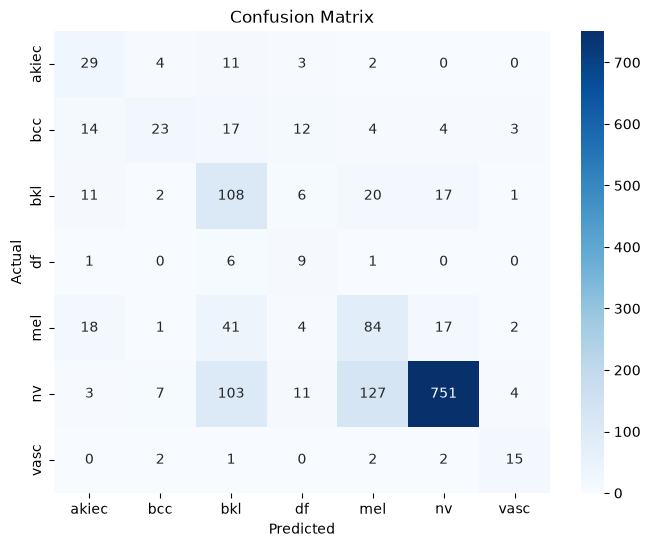

In [49]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

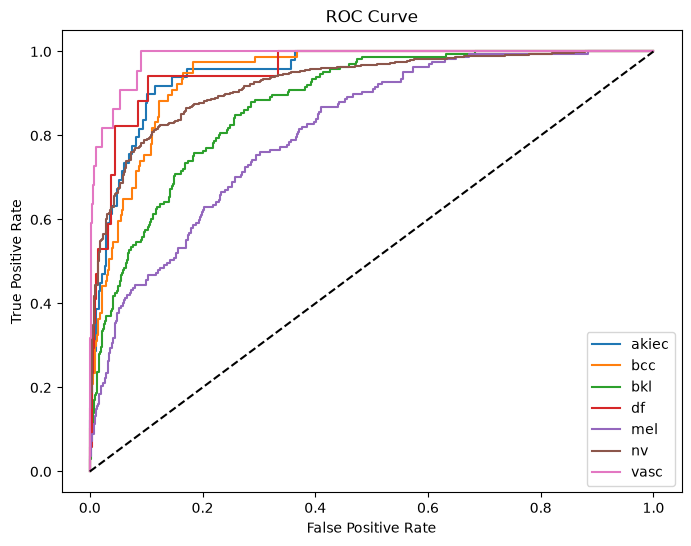

In [53]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

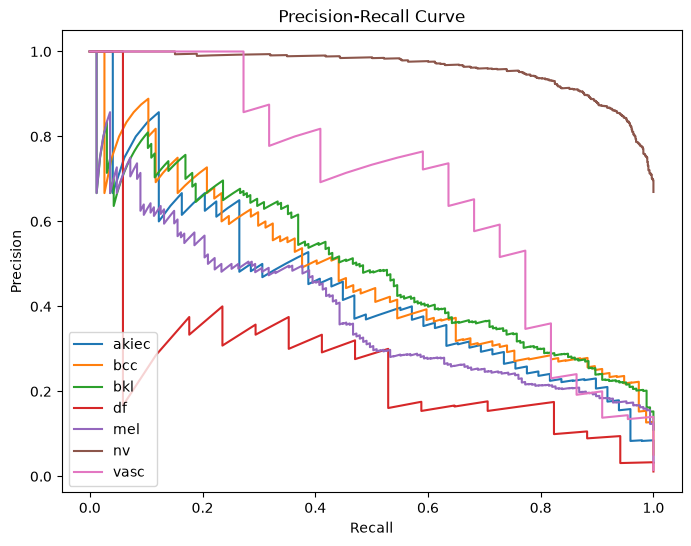

In [54]:
# prediction recall curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    precision_curve, recall_curve, _ = precision_recall_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(recall_curve,precision_curve,label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-94.779..84.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..137.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-98.939..131.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-100.779..83.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-75.779..123.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-67.779..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-102.779..142.061].
Clipping input data t

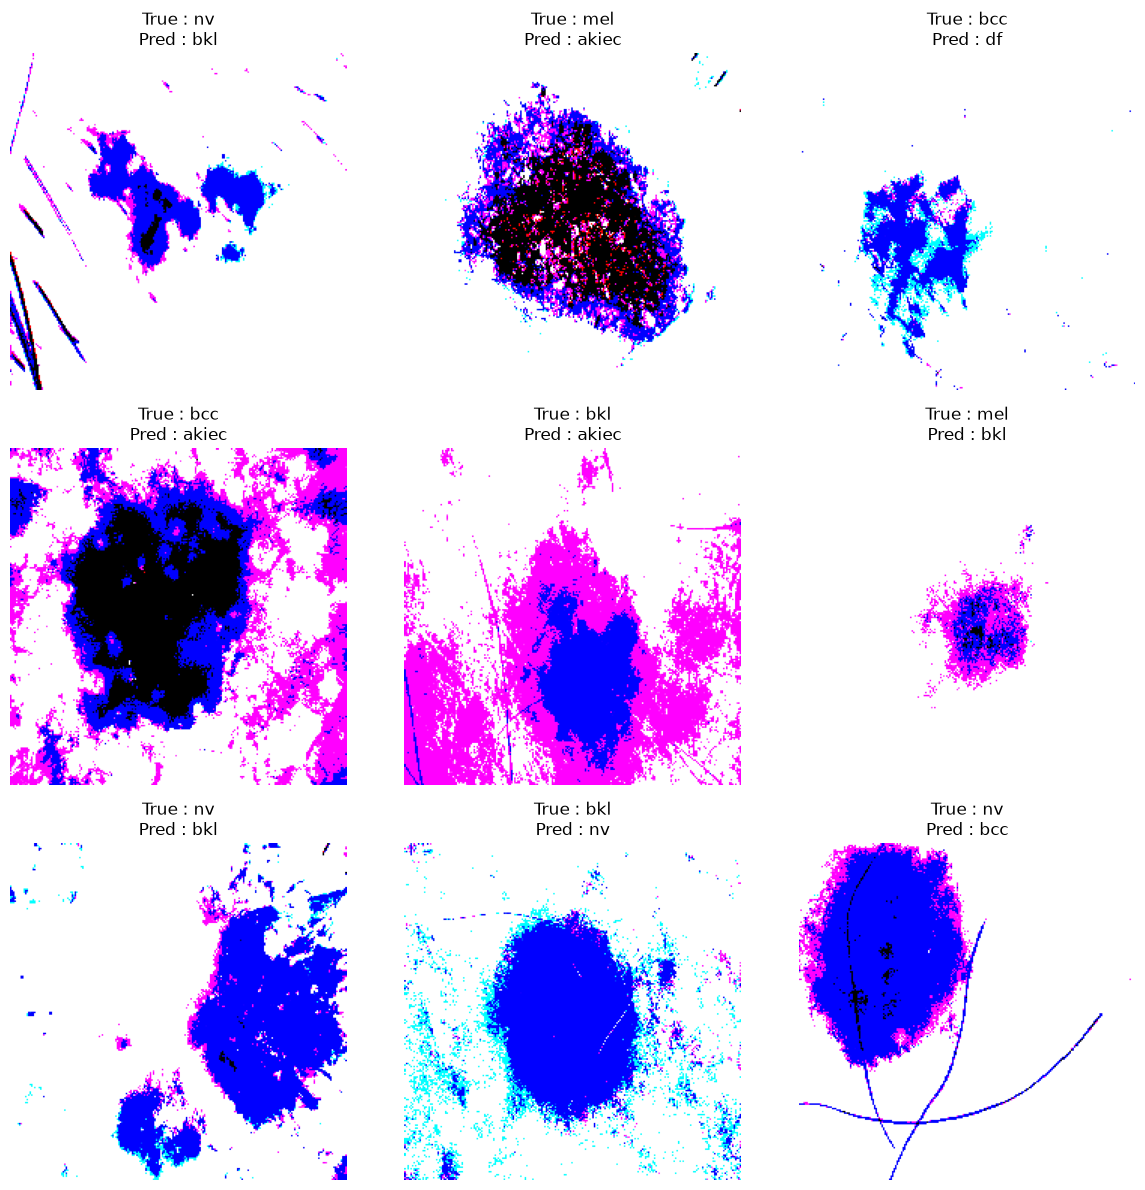

In [55]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(12,12))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator_resnet[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

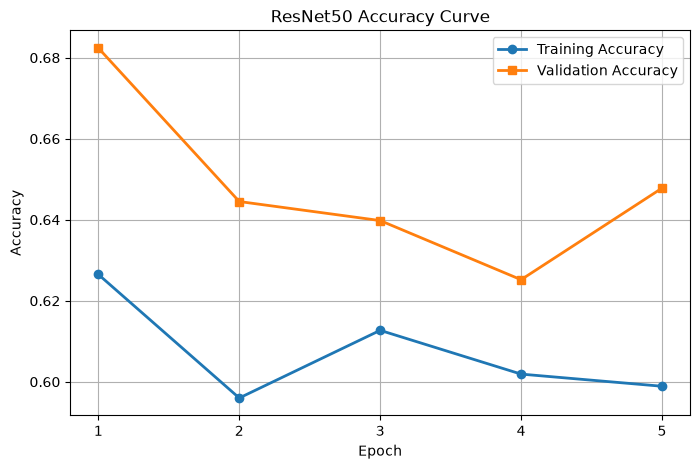

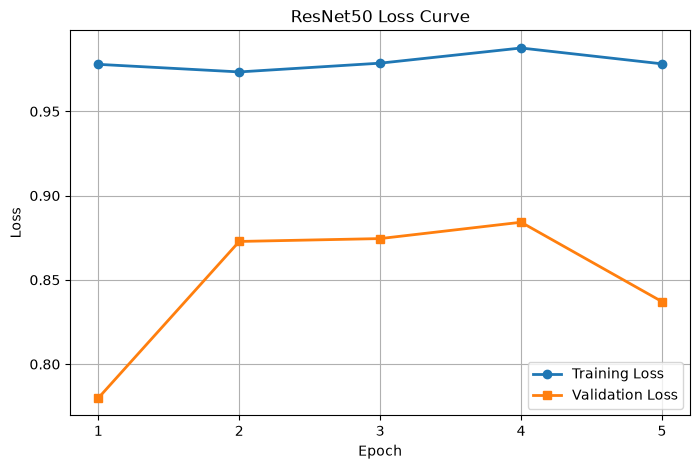

In [127]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4, 5]

train_acc = [0.6265, 0.5960, 0.6127, 0.6019, 0.5989]

val_acc = [0.6824, 0.6445, 0.6398, 0.6252, 0.6478]

train_loss = [0.9779, 0.9734, 0.9786, 0.9876, 0.9782]

val_loss = [0.7799, 0.8728, 0.8745, 0.8842, 0.8371]

# Accuracy Curve

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_acc, marker='s', linewidth=2, label='Validation Accuracy')

plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.savefig("resnet50_accuracy_curve.png", dpi=300)
plt.show()

# Loss Curve

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, marker='s', linewidth=2, label='Validation Loss')

plt.title("ResNet50 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.savefig("resnet50_loss_curve.png", dpi=300)
plt.show()

## DenseNet121

In [14]:
desnet_model_hyper = load_model("DenseNet121_best_model.keras")

In [15]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input


# image generators
train_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_datagen_dense = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_dense = ImageDataGenerator(preprocessing_function=preprocess_input)


In [16]:
# data generators
train_generator_dense = train_datagen_dense.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_dense = val_datagen_dense.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_dense = test_datagen_dense.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [18]:
train_pred = desnet_model_hyper.predict(train_generator_dense)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

220/220 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 625,  505,  810,  392, 1102, 3385,  191]))


In [24]:
test_generator_dense.reset()
pred = desnet_model_hyper.predict(test_generator_dense, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator_dense.classes
class_names = list(test_generator_dense.class_indices.keys())

In [25]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6500332667997338
Precision: 0.7603645765721659
Recall   : 0.6500332667997338
F1 Score : 0.6868572046385545


In [27]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8964584387935949


In [23]:
evaluation.append({
    "Model" : "DenseNet121",
    "Accuracy" : 0.650033,
    "Precision" : 0.760364,
    "Recall" : 0.650033,
    "F1Score" : 0.686857,
    " ROU-AOC" : 0.896458,
    
})

In [24]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458


In [26]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.39      0.61      0.48        49
         bcc       0.44      0.45      0.45        77
         bkl       0.39      0.56      0.46       165
          df       0.12      0.47      0.19        17
         mel       0.31      0.47      0.38       167
          nv       0.96      0.71      0.82      1006
        vasc       0.44      0.77      0.56        22

    accuracy                           0.65      1503
   macro avg       0.43      0.58      0.47      1503
weighted avg       0.76      0.65      0.69      1503



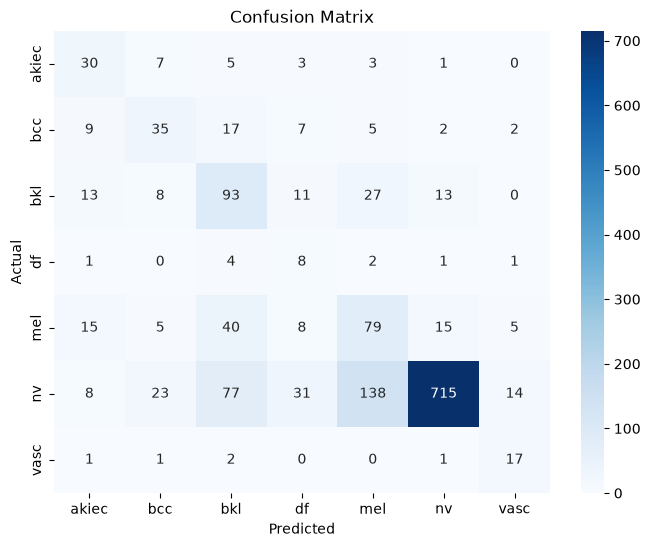

In [28]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

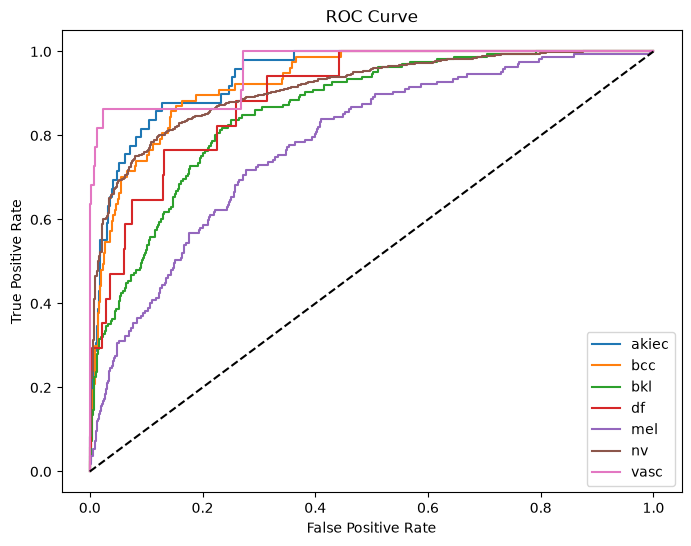

In [29]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.7859696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.317927..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.177871..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7870152..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7380952..2.1975338].


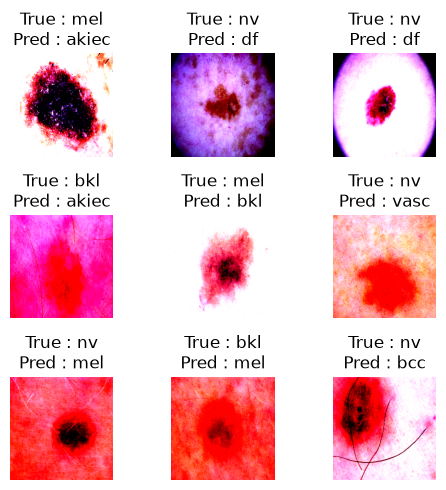

In [41]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(5,5))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator_dense[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## EfficientNet

In [163]:
from tensorflow.keras.applications.efficientnet import preprocess_input
# create new data generator
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [164]:
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_eff = val_datagen_eff.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_eff = test_datagen_eff.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [165]:
efficient_hyper = load_model("effiecientbo_best_model.keras")

In [166]:
train_pred = efficient_hyper.predict(train_generator_eff)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

220/220 ━━━━━━━━━━━━━━━━━━━━ 129s 580ms/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 333,  483,  794,  208, 1492, 3491,  209]))


In [167]:
test_generator_eff.reset()
pred = efficient_hyper.predict(test_generator_eff, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator_eff.classes
class_names = list(test_generator_eff.class_indices.keys())

In [168]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.80      0.33      0.46        49
         bcc       0.69      0.57      0.62        77
         bkl       0.47      0.65      0.54       165
          df       0.36      0.53      0.43        17
         mel       0.29      0.73      0.42       167
          nv       0.97      0.67      0.79      1006
        vasc       0.45      0.95      0.61        22

    accuracy                           0.66      1503
   macro avg       0.57      0.63      0.55      1503
weighted avg       0.80      0.66      0.70      1503



In [169]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6626746506986028
Precision: 0.8037580897281386
Recall   : 0.6626746506986028
F1 Score : 0.6980661741060764


In [170]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.9313456215307856


In [25]:
evaluation.append({
    "Model" : "EfficientNet",
    "Accuracy" : 0.662675,
    "Precision" : 0.803758,
    "Recall" : 0.662674,
    "F1Score" : 0.698066,
    " ROU-AOC" : 0.931345 ,
    
})

In [26]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345


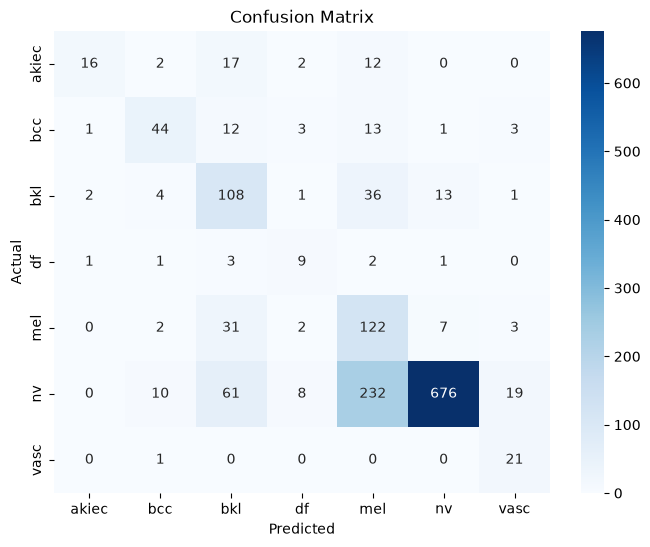

In [173]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

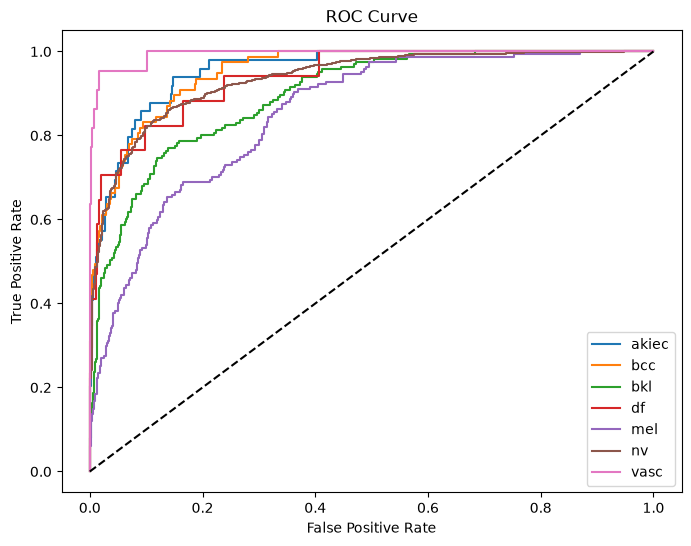

In [174]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Batch Normalization

In [46]:
bn_model= load_model("models2/batch_cnn_batch16.keras")

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2]
)

# Validation Generator
val_datagen = ImageDataGenerator(
    rescale=1./255
)
# Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
# create train  pipeline
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)
# create validatation pipeline
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# create test pipeline
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,

    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [50]:
train_pred = bn_model.predict(test_generator)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 333ms/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 34,  23, 367, 132, 210, 711,  26]))


In [51]:
test_generator.reset()
pred = bn_model.predict(test_generator, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

In [52]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6167664670658682
Precision: 0.7694484814579459
Recall   : 0.6167664670658682
F1 Score : 0.6601755744458682


In [57]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.9031960192266212


In [27]:
evaluation.append({
    "Model" : "Batch Normalization",
    "Accuracy" : 0.616766,
    "Precision" : 0.769448,
    "Recall" : 0.616766,
    "F1Score" : 0.660176,
    " ROU-AOC" : 0.903196,
    
})

In [28]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345
3,Batch Normalization,0.616766,0.769448,0.616766,0.660176,0.903196


In [56]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.47      0.33      0.39        49
         bcc       0.57      0.17      0.26        77
         bkl       0.31      0.70      0.43       165
          df       0.08      0.59      0.13        17
         mel       0.37      0.46      0.41       167
          nv       0.96      0.68      0.79      1006
        vasc       0.62      0.73      0.67        22

    accuracy                           0.62      1503
   macro avg       0.48      0.52      0.44      1503
weighted avg       0.77      0.62      0.66      1503



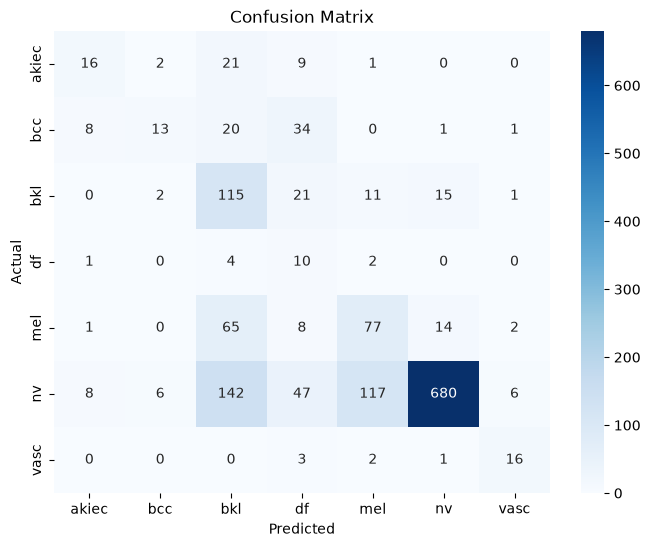

In [58]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

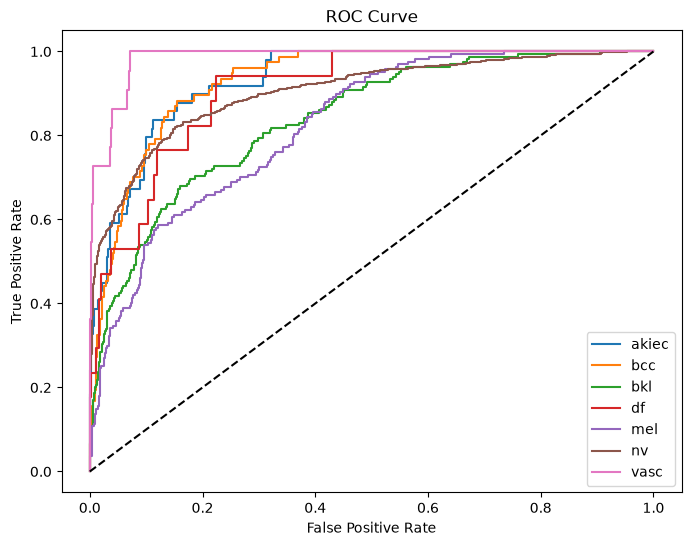

In [59]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.4722441].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4404761..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7172985..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.7859696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556022.

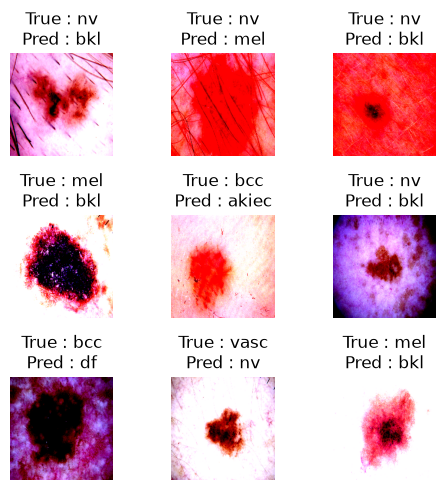

In [60]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(5,5))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator_dense[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Basic CNN

In [85]:
basic_model= load_model("models2/basic_cnn_earlystop.keras")

In [86]:
train_pred = basic_model.predict(test_generator)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 90,  83, 127,  69, 228, 834,  72]))


In [87]:
test_generator.reset()
pred = basic_model.predict(test_generator, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

In [88]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6167664670658682
Precision: 0.6973279528201809
Recall   : 0.6167664670658682
F1 Score : 0.6469653278268547


In [92]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8682989463027477


In [29]:
evaluation.append({
    "Model" : "Basic CNN",
    "Accuracy" : 0.616766,
    "Precision" : 0.6973279,
    "Recall" :0.6167664,
    "F1Score" : 0.646965,
    " ROU-AOC" : 0.868299,
    
})

In [30]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345
3,Batch Normalization,0.616766,0.769448,0.616766,0.660176,0.903196
4,Basic CNN,0.616766,0.697328,0.616766,0.646965,0.868299


In [91]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.28      0.51      0.36        49
         bcc       0.37      0.40      0.39        77
         bkl       0.39      0.30      0.34       165
          df       0.06      0.24      0.09        17
         mel       0.28      0.38      0.32       167
          nv       0.88      0.73      0.80      1006
        vasc       0.24      0.77      0.36        22

    accuracy                           0.62      1503
   macro avg       0.36      0.48      0.38      1503
weighted avg       0.70      0.62      0.65      1503



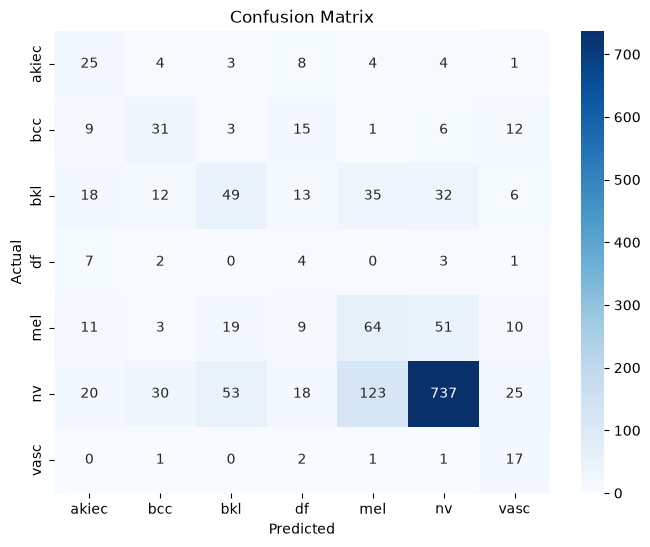

In [93]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

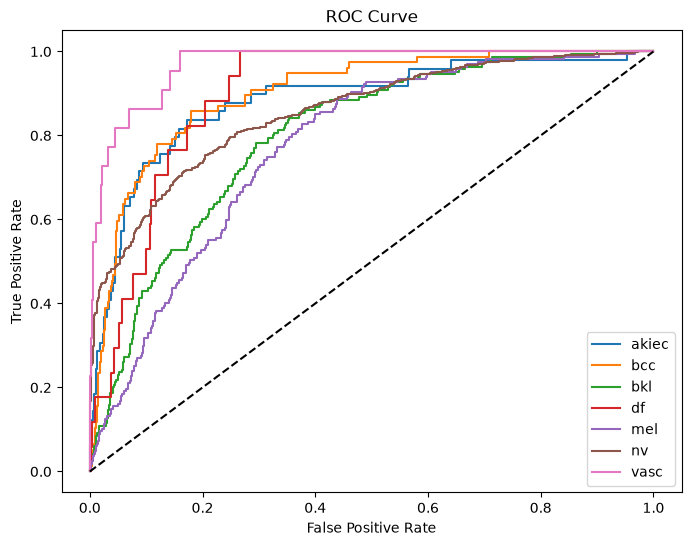

In [94]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.4722441].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4404761..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7731092..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7172985..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.7859696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556022.

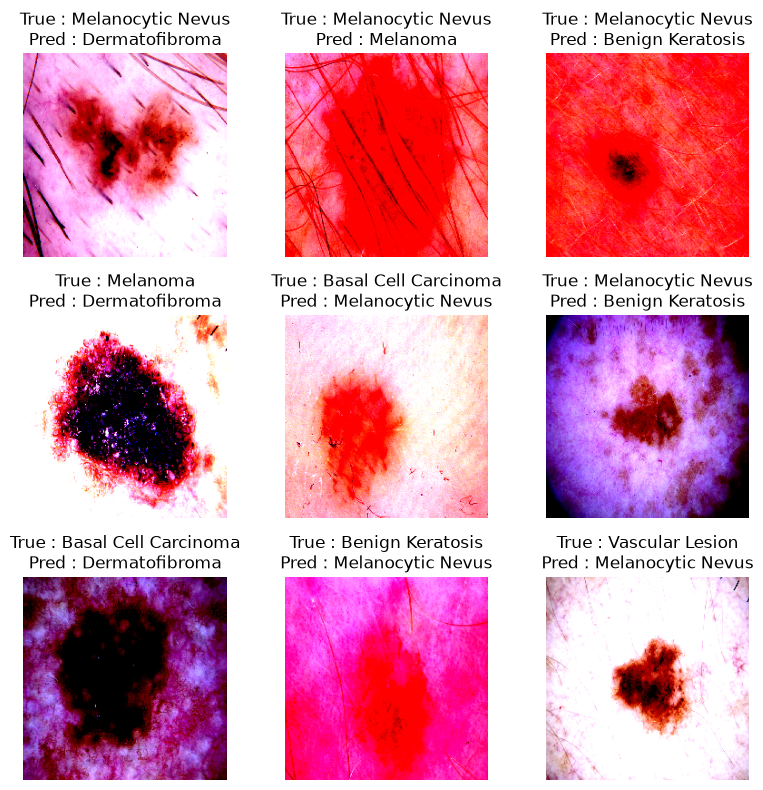

In [100]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(8,8))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator_mobile[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## MobileNetV2

In [69]:
mobile_model= load_model("models2/mobilenetv2_RMSprop.keras")

In [70]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input


# image generators
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_datagen_mobile= ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mobile= ImageDataGenerator(preprocessing_function=preprocess_input)


In [71]:
# data generators
train_generator_mobile = train_datagen_dense.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobile = val_datagen_dense.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobile = test_datagen_dense.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [72]:
train_pred = mobile_model.predict(test_generator_mobile)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 393ms/step
(array([0, 1, 2, 3, 4, 5, 6]), array([ 98, 101, 117,  11, 416, 709,  51]))


In [73]:
test_generator_mobile.reset()
pred = mobile_model.predict(test_generator_mobile, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator_mobile.classes
class_names = list(test_generator_mobile.class_indices.keys())

In [74]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.590818363273453
Precision: 0.7250344290271207
Recall   : 0.590818363273453
F1 Score : 0.6295656237850971


In [78]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8533494911296756


In [31]:
evaluation.append({
    "Model" : "MobileNetV2",
    "Accuracy" : 0.590818,
    "Precision" : 0.7250344,
    "Recall" :0.590818,
    "F1Score" : 0.6295656,
    " ROU-AOC" : 0.853349,
    
})

In [32]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345
3,Batch Normalization,0.616766,0.769448,0.616766,0.660176,0.903196
4,Basic CNN,0.616766,0.697328,0.616766,0.646965,0.868299
5,MobileNetV2,0.590818,0.725034,0.590818,0.629566,0.853349


In [77]:
#classification reports
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.29      0.57      0.38        49
         bcc       0.47      0.61      0.53        77
         bkl       0.48      0.34      0.40       165
          df       0.27      0.18      0.21        17
         mel       0.24      0.59      0.34       167
          nv       0.91      0.64      0.75      1006
        vasc       0.25      0.59      0.36        22

    accuracy                           0.59      1503
   macro avg       0.41      0.50      0.42      1503
weighted avg       0.73      0.59      0.63      1503



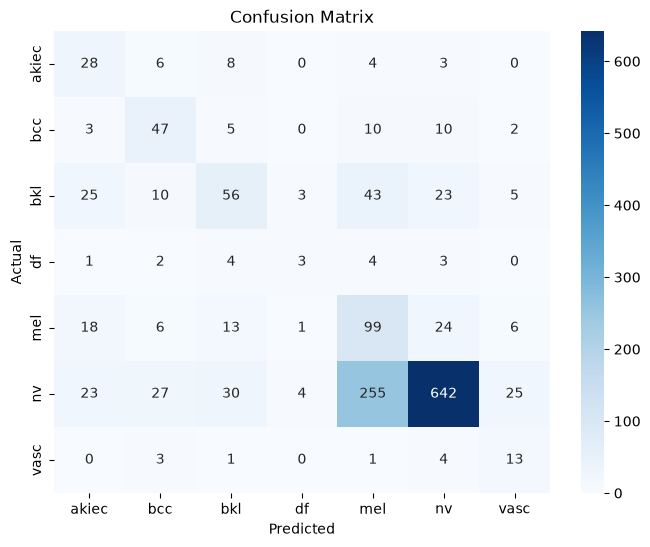

In [79]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

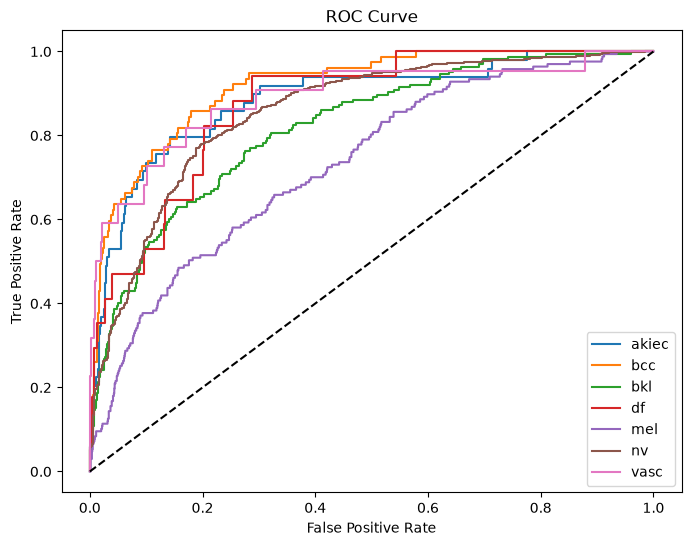

In [80]:
# ROC curve
plt.figure(figsize=(8,6))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        true_labels_bin[:,i],
        pred[:,i]
    )

    plt.plot(fpr,tpr,label=class_names[i])

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.4722441].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4404761..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.317927..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.177871..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..1.733682].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5805322..2.2489083

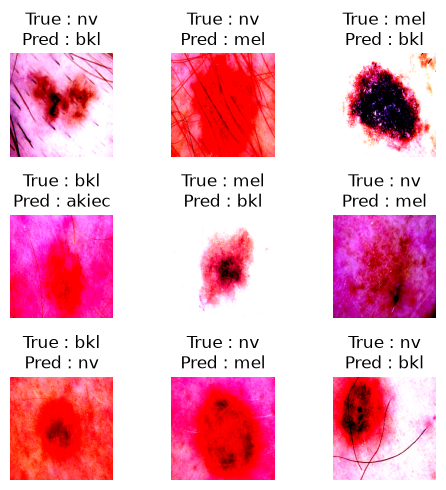

In [83]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(5,5))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator_mobile[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Deep CNN

In [129]:
DEEP_model= load_model("models2/deep_cnn_hyperparameter_finalll.keras")

In [141]:
train_pred = DEEP_model.predict(test_generator)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step
(array([2, 5]), array([  37, 1466]))


In [142]:
test_generator.reset()
pred = DEEP_model.predict(test_generator, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

In [143]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

/Users/aximsoft/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy : 0.6753160345974717
Precision: 0.4960521786705709
Recall   : 0.6753160345974717
F1 Score : 0.5567407272673084


In [144]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8059717318447784


In [33]:
evaluation.append({
    "Model" : "DeepCnnV2",
    "Accuracy" : 0.6753160,
    "Precision" : 0.4960521,
    "Recall" :0.590818,
    "F1Score" : 0.6753160,
    " ROU-AOC" : 0.8059717,
    
})

In [34]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345
3,Batch Normalization,0.616766,0.769448,0.616766,0.660176,0.903196
4,Basic CNN,0.616766,0.697328,0.616766,0.646965,0.868299
5,MobileNetV2,0.590818,0.725034,0.590818,0.629566,0.853349
6,DeepCnnV2,0.675316,0.496052,0.590818,0.675316,0.805972


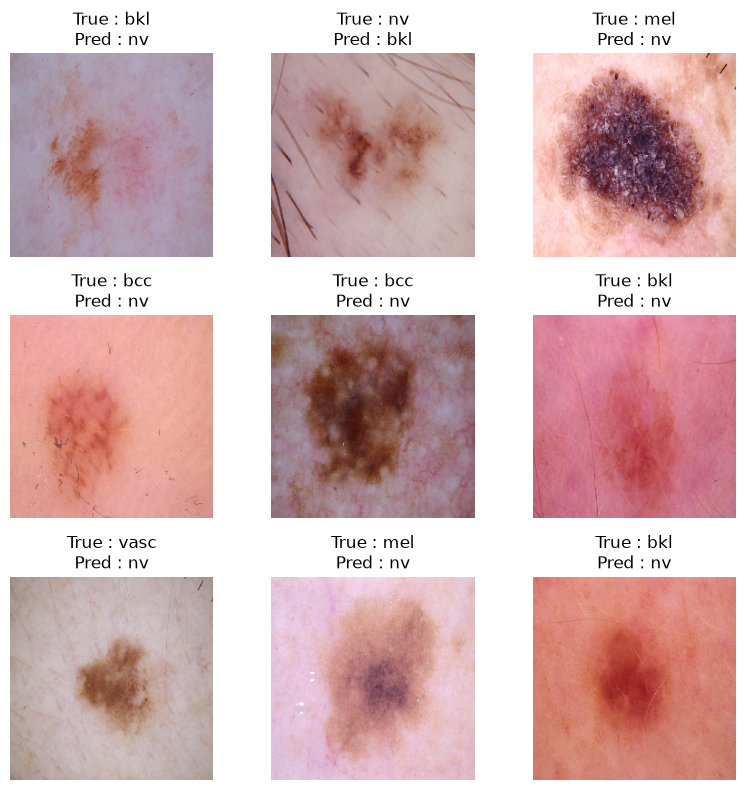

In [149]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(8,8))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Dropout

In [3]:
batch_model= load_model("models/cnn_dropout_hyperparameter.keras")

In [15]:
train_pred = batch_model.predict(train_generator)
train_pred_classes = np.argmax(train_pred, axis=1)
print(np.unique(train_pred_classes, return_counts=True))

220/220 ━━━━━━━━━━━━━━━━━━━━ 57s 260ms/step
(array([2, 5, 6]), array([   1, 6987,   22]))


In [16]:
test_generator.reset()
pred = batch_model.predict(test_generator, verbose=0)
pred_labels = np.argmax(pred, axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

In [17]:
accuracy = accuracy_score(true_labels, pred_labels)

precision = precision_score(
    true_labels,
    pred_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    pred_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    pred_labels,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6713240186294078
Precision: 0.4607584119700075
Recall   : 0.6713240186294078
F1 Score : 0.5416170774453144


/Users/aximsoft/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
# ROU-AOU score
true_labels_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)

roc_auc = roc_auc_score(
    true_labels_bin,
    pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8272834860542019


In [35]:
evaluation.append({
    "Model" : "Batch Normalization",
    "Accuracy" : 0.6753160,
    "Precision" : 0.4960521,
    "Recall" :0.590818,
    "F1Score" : 0.6753160,
    " ROU-AOC" : 0.8059717,
    
})

In [36]:
evaluation_comparison = pd.DataFrame(evaluation)
evaluation_comparison

,Model,Accuracy,Precision,Recall,F1Score,ROU-AOC
0,ResNet50,0.677977,0.769378,0.677977,0.705844,0.919638
1,DenseNet121,0.650033,0.760364,0.650033,0.686857,0.896458
2,EfficientNet,0.662675,0.803758,0.662674,0.698066,0.931345
3,Batch Normalization,0.616766,0.769448,0.616766,0.660176,0.903196
4,Basic CNN,0.616766,0.697328,0.616766,0.646965,0.868299
5,MobileNetV2,0.590818,0.725034,0.590818,0.629566,0.853349
6,DeepCnnV2,0.675316,0.496052,0.590818,0.675316,0.805972
7,Batch Normalization,0.675316,0.496052,0.590818,0.675316,0.805972


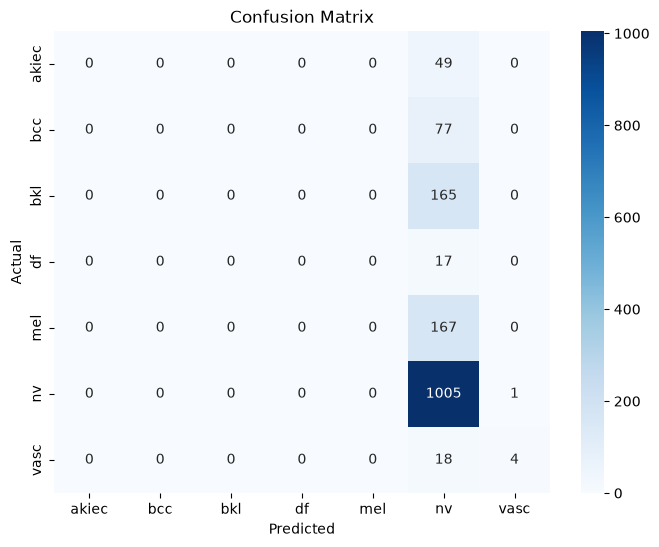

In [19]:
# confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("images/batchnor_confusionmatrix.png", dpi=300, bbox_inches="tight")

plt.show()

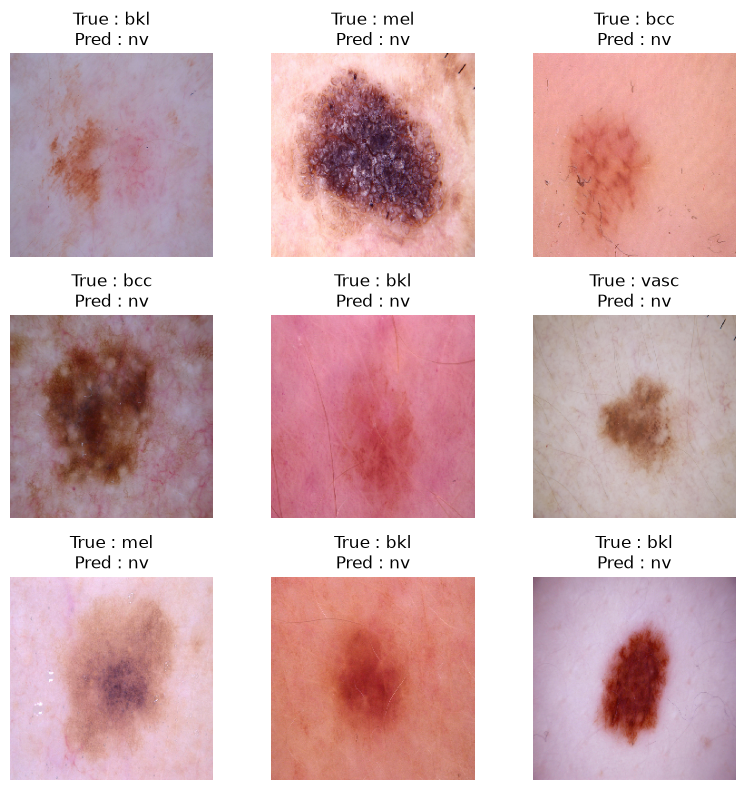

In [21]:
# 
errors = np.where(pred_labels != true_labels)[0]

plt.figure(figsize=(8,8))

for i, idx in enumerate(errors[:9]):

    plt.subplot(3,3,i+1)

    image = test_generator[idx][0][0]

    plt.imshow(image)

    plt.title(
        f"True : {class_names[true_labels[idx]]}\nPred : {class_names[pred_labels[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig("images/GRAD-CAM.png", dpi=300, bbox_inches="tight")

plt.show()

In [37]:
evaluation_comparison.to_csv("dataset/evaluation_comparison.csv", index = False)
print("csv_saved")

csv_saved
